In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.metrics import accuracy_score
import mlflow
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report

c:\Users\NishantHP\Desktop\MLOps project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%pwd

'c:\\Users\\NishantHP\\Desktop\\MLOps project\\research'

In [3]:
 os.chdir('c:\\Users\\NishantHP\\Desktop\\MLOPS PROJECT')

In [4]:
df=pd.read_csv('artifacts/data_ingestion/telcom.csv')

In [5]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_grp,monthly_charge,Total_services
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,1,0-1yrs,low,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.5,1,2-3yrs,medium,3
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,0,0-1yrs,medium,3
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,1,3-4yrs,low,3
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,0,0-1yrs,medium,1


In [6]:
#df['Churn']=df['Churn'].map({'Yes':0,'No':1})

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,Churn,Total_services
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,0.734630,3.362914
std,0.368612,24.559481,30.090047,0.441561,2.062031
min,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,0.000000,1.000000
50%,0.000000,29.000000,70.350000,1.000000,3.000000
75%,0.000000,55.000000,89.850000,1.000000,5.000000
max,1.000000,72.000000,118.750000,1.000000,8.000000


In [8]:
df['tenure_grp']=pd.cut(df['tenure'],
                        bins=[0,12,24,36,48,60,72],
                        labels=['0-1yrs','1-2yrs','2-3yrs','3-4yrs','4-5yrs','5-6yrs'],
                        include_lowest=True)

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isna().sum()

np.int64(11)

In [10]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

In [11]:
df['TotalCharges'].isna().sum()

np.int64(0)

In [12]:
df['monthly_charge']=pd.cut(df['MonthlyCharges'],bins=3,labels=['low','medium','high'])

In [13]:
#df.drop('customerID',axis=1)

In [14]:
services = ['PhoneService', 'MultipleLines', 'InternetService',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']
df['Total_services']=df[services].apply(lambda x:(x=='Yes').sum() ,axis=1)

In [15]:
X=df.drop('Churn',axis=1)
y=df['Churn']

In [16]:
num_feat=make_column_selector(dtype_exclude=['object','category'])
cat_feat=make_column_selector(dtype_include=['object','category'])

num_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())])

cat_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore', drop='first'))])

preprocessor=ColumnTransformer([
    ('num',num_pipeline,num_feat),
    ('cat',cat_pipeline,cat_feat)])

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])


In [17]:
param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear'],
    'model__class_weight': [None, 'balanced']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2,
    error_score='raise'
)

In [18]:
X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_grp,monthly_charge,Total_services
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,1,0-1yrs,low,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,1,2-3yrs,medium,3
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,0,0-1yrs,medium,3
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,1,3-4yrs,low,3
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,0,0-1yrs,medium,1


In [20]:
glr=grid.fit(X_train,Y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


c:\Users\NishantHP\Desktop\MLOps project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [21]:
print("Best Params:", glr.best_params_)
print("Best Score:", glr.best_score_)

best_model = glr.best_estimator_


Best Params: {'model__C': 10, 'model__class_weight': None, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best Score: 0.8430813467897196


In [22]:
params=glr.best_params_
params

{'model__C': 10,
 'model__class_weight': None,
 'model__penalty': 'l2',
 'model__solver': 'liblinear'}

In [23]:
yped= grid.predict(X_test)
score=accuracy_score(Y_test,yped)
score

0.8147622427253371

In [24]:
report = classification_report(Y_test,yped,output_dict=True)
report

{'0': {'precision': 0.6761006289308176,
  'recall': 0.5764075067024129,
  'f1-score': 0.622286541244573,
  'support': 373.0},
 '1': {'precision': 0.8551787351054079,
  'recall': 0.9005791505791506,
  'f1-score': 0.8772919605077574,
  'support': 1036.0},
 'accuracy': 0.8147622427253371,
 'macro avg': {'precision': 0.7656396820181127,
  'recall': 0.7384933286407818,
  'f1-score': 0.7497892508761652,
  'support': 1409.0},
 'weighted avg': {'precision': 0.8077719688860167,
  'recall': 0.8147622427253371,
  'f1-score': 0.8097852029597321,
  'support': 1409.0}}

In [25]:

mlflow.set_tracking_uri('http://127.0.0.1:5000/')

mlflow.set_experiment('1st experiment v2')
with mlflow.start_run():
    mlflow.log_params(params)
    mlflow.log_metric("accuracy", report["accuracy"])
    
    mlflow.log_metric("precision_class_0", report["0"]["precision"])
    mlflow.log_metric("recall_class_0", report["0"]["recall"])
    mlflow.log_metric("f1_class_0", report["0"]["f1-score"])
    
    mlflow.log_metric("precision_class_1", report["1"]["precision"])
    mlflow.log_metric("recall_class_1", report["1"]["recall"])
    mlflow.log_metric("f1_class_1", report["1"]["f1-score"])
    mlflow.sklearn.log_model(glr,'LogisticRegression')

2026/04/17 15:54:25 INFO mlflow.tracking.fluent: Experiment with name '1st experiment v2' does not exist. Creating a new experiment.
2026/04/17 15:54:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/17 15:54:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run colorful-mare-628 at: http://127.0.0.1:5000/#/experiments/2/runs/5d1f7134844644ee97bd7e44d6a091a8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


In [26]:
rp=classification_report(Y_test,yped)
print(rp)

              precision    recall  f1-score   support

           0       0.68      0.58      0.62       373
           1       0.86      0.90      0.88      1036

    accuracy                           0.81      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.81      0.81      1409



<Axes: ylabel='Frequency'>

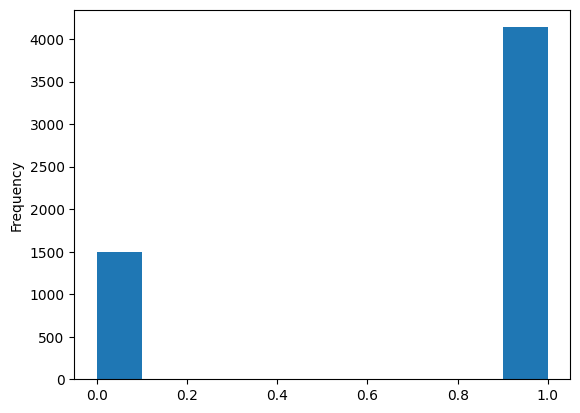

In [27]:
Y_train.plot(kind='hist')

In [28]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train = pd.get_dummies(X_train)
X_train_res, y_train_res = smote.fit_resample(X_train,Y_train)

In [29]:
Y_train.isnull().sum()

np.int64(0)

In [30]:
X_train

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Total_services,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,...,PaymentMethod_Mailed check,tenure_grp_0-1yrs,tenure_grp_1-2yrs,tenure_grp_2-3yrs,tenure_grp_3-4yrs,tenure_grp_4-5yrs,tenure_grp_5-6yrs,monthly_charge_low,monthly_charge_medium,monthly_charge_high
2142,0,21,64.85,1336.800,4,True,False,True,False,False,...,True,False,True,False,False,False,False,False,True,False
1623,0,54,97.20,5129.450,5,True,False,True,False,True,...,False,False,False,False,False,True,False,False,False,True
6074,0,1,23.45,23.450,0,False,True,False,True,True,...,False,True,False,False,False,False,False,True,False,False
1362,0,4,70.20,237.950,1,False,True,True,False,True,...,False,True,False,False,False,False,False,False,True,False
6754,0,0,61.90,1397.475,5,False,True,True,False,False,...,False,True,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,0,1,95.00,95.000,4,False,True,False,True,True,...,False,True,False,False,False,False,False,False,False,True
5191,0,23,91.10,2198.300,8,True,False,False,True,False,...,False,False,True,False,False,False,False,False,False,True
5226,0,12,21.15,306.050,1,False,True,False,True,False,...,False,True,False,False,False,False,False,True,False,False
5390,1,12,99.45,1200.150,5,False,True,True,False,True,...,False,True,False,False,False,False,False,False,False,True


<Axes: ylabel='Frequency'>

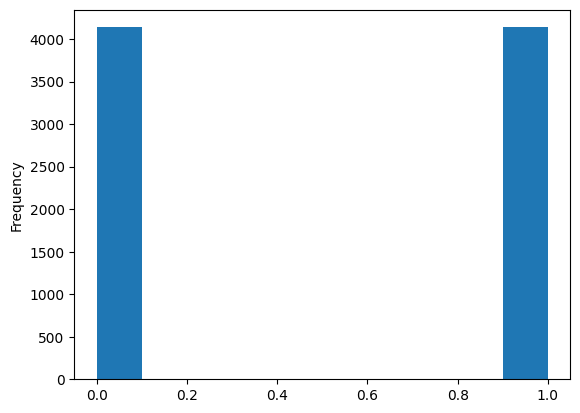

In [31]:
y_train_res.plot(kind='hist')

In [32]:
g2=grid.fit(X_train_res,y_train_res)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


c:\Users\NishantHP\Desktop\MLOps project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [33]:
X_train_res.shape

(8276, 55)

In [34]:
print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

best_model = grid.best_estimator_


Best Params: {'model__C': 10, 'model__class_weight': 'balanced', 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best Score: 0.9402317313677345


In [35]:
X_test = pd.get_dummies(X_test)
yped2= g2.predict(X_test)
score2=accuracy_score(Y_test,yped2)
score2

0.8140525195173882

In [36]:
params=g2.best_params_
params

{'model__C': 10,
 'model__class_weight': 'balanced',
 'model__penalty': 'l2',
 'model__solver': 'liblinear'}

In [37]:
report = classification_report(Y_test,yped2,output_dict=True)
report

{'0': {'precision': 0.6646884272997032,
  'recall': 0.6005361930294906,
  'f1-score': 0.6309859154929578,
  'support': 373.0},
 '1': {'precision': 0.8610074626865671,
  'recall': 0.890926640926641,
  'f1-score': 0.8757115749525617,
  'support': 1036.0},
 'accuracy': 0.8140525195173882,
 'macro avg': {'precision': 0.7628479449931351,
  'recall': 0.7457314169780658,
  'f1-score': 0.7533487452227597,
  'support': 1409.0},
 'weighted avg': {'precision': 0.809036561196645,
  'recall': 0.8140525195173882,
  'f1-score': 0.8109261448756048,
  'support': 1409.0}}

In [38]:

mlflow.set_tracking_uri('http://127.0.0.1:5000/')

mlflow.set_experiment('2nd experiment')
with mlflow.start_run():
    mlflow.log_params(params)
    mlflow.log_metric("accuracy", report["accuracy"])
    
    mlflow.log_metric("precision_class_0", report["0"]["precision"])
    mlflow.log_metric("recall_class_0", report["0"]["recall"])
    mlflow.log_metric("f1_class_0", report["0"]["f1-score"])
    
    mlflow.log_metric("precision_class_1", report["1"]["precision"])
    mlflow.log_metric("recall_class_1", report["1"]["recall"])
    mlflow.log_metric("f1_class_1", report["1"]["f1-score"])
    mlflow.sklearn.log_model(g2,'LogisticRegression')

2026/04/17 15:55:10 INFO mlflow.tracking.fluent: Experiment with name '2nd experiment' does not exist. Creating a new experiment.
2026/04/17 15:55:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/17 15:55:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run delicate-steed-346 at: http://127.0.0.1:5000/#/experiments/3/runs/db3a80645b694fcb8d4eaa214c86f491
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


In [39]:
X_test.shape

(1409, 55)

In [40]:
rp2=classification_report(Y_test,yped2)
print(rp2)

              precision    recall  f1-score   support

           0       0.66      0.60      0.63       373
           1       0.86      0.89      0.88      1036

    accuracy                           0.81      1409
   macro avg       0.76      0.75      0.75      1409
weighted avg       0.81      0.81      0.81      1409



In [92]:
params = {
    "C": 1.0,
    "penalty": "l2",
    "solver": "liblinear",
    "max_iter": 1000,
    "class_weight": {0:1.62, 1:1}
}

lr = LogisticRegression(**params)
X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train=preprocessor.fit_transform(X_train)
X_test=preprocessor.transform(X_test)
lr.fit(X_train,Y_train)

c:\Users\NishantHP\Desktop\MLOps project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*","{0: 1.62, 1: 1}"
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term

In [93]:
yped=lr.predict(X_test)
sr=classification_report(Y_test,yped)
print(sr)

              precision    recall  f1-score   support

           0       0.61      0.72      0.66       373
           1       0.89      0.83      0.86      1036

    accuracy                           0.80      1409
   macro avg       0.75      0.77      0.76      1409
weighted avg       0.82      0.80      0.81      1409



In [94]:
report = classification_report(Y_test,yped,output_dict=True)
report

{'0': {'precision': 0.6054421768707483,
  'recall': 0.7158176943699732,
  'f1-score': 0.6560196560196561,
  'support': 373.0},
 '1': {'precision': 0.890495867768595,
  'recall': 0.832046332046332,
  'f1-score': 0.8602794411177644,
  'support': 1036.0},
 'accuracy': 0.801277501774308,
 'macro avg': {'precision': 0.7479690223196717,
  'recall': 0.7739320132081526,
  'f1-score': 0.7581495485687102,
  'support': 1409.0},
 'weighted avg': {'precision': 0.8150345287303432,
  'recall': 0.801277501774308,
  'f1-score': 0.8062064107120906,
  'support': 1409.0}}

In [95]:

mlflow.set_tracking_uri('http://127.0.0.1:5000/')
mlflow.set_experiment('5th experiment')

with mlflow.start_run():
    mlflow.log_params(params)
    mlflow.log_metric("accuracy", report["accuracy"])
    
    mlflow.log_metric("precision_class_0", report["0"]["precision"])
    mlflow.log_metric("recall_class_0", report["0"]["recall"])
    mlflow.log_metric("f1_class_0", report["0"]["f1-score"])
    
    mlflow.log_metric("precision_class_1", report["1"]["precision"])
    mlflow.log_metric("recall_class_1", report["1"]["recall"])
    mlflow.log_metric("f1_class_1", report["1"]["f1-score"])
    mlflow.sklearn.log_model(g2,'LogisticRegression')

2026/04/17 16:29:08 INFO mlflow.tracking.fluent: Experiment with name '5th experiment' does not exist. Creating a new experiment.
2026/04/17 16:29:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/17 16:29:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run brawny-turtle-182 at: http://127.0.0.1:5000/#/experiments/6/runs/ec22619a2fe145b6a221ff9d0676dfa3
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/6
